# Analisis Pola Kualitas Udara Perkotaan di India

* **Nomor Kelompok**: 4
* **Nama & NRP Anggota**:
  1. Josua Christiano Nathanael Sihite - 5027261002
  2. Fadli Azzaki - 5027261014
  3. Muhammad Haris - 5027261041
* **Topik yang Dipilih**: Smart City (Air Data in India 2015-2024)

## Latar Belakang dan Pertanyaan

Analisis kualitas udara sangat menarik dilakukan karena polusi udara merupakan isu krusial di perkotaan modern yang berdampak langsung pada kesehatan masyarakat. Melalui dataset harian ini, kita dapat memahami fluktuasi tingkat polutan berbahaya di berbagai wilayah.

**Pertanyaan Analisis:**
1. Berapa rata-rata dan seberapa besar variasi konsentrasi polutan $PM_{2.5}$ dalam pengukuran harian?
2. Bagaimana sebaran tingkat kategori kualitas udara (*AQI_Bucket*) yang paling sering dialami?
3. Apakah terdapat hubungan antara kadar gas Nitrogen Dioksida ($NO_2$) dengan nilai Indeks Kualitas Udara (AQI)?

In [78]:
import pandas as pd

df = pd.read_csv("city_day.csv")
print(df.shape)   # (jumlah baris, jumlah kolom)
df.head()

(18265, 16)


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good


### Penjelasan Struktur Data:
* **Setiap baris mewakili**: Satu hari pengamatan kualitas udara (*one day observation*) untuk masing-masing kota tertentu di India.
* Berdasarkan output `df.shape`, dataset ini memiliki jumlah baris dan kolom yang cukup besar untuk menganalisis berbagai parameter polutan harian seperti $PM_{2.5}$, $NO_2$, dan status indeks kualitas udara (*AQI*).

### Deskripsi Data dan Kamus Data

* **Sumber Data & Lisensi**: Dataset diambil dari Kaggle dengan judul *"India Air Quality Data (2015-2024)"* yang bersumber dari data publik pemantauan kualitas udara pemerintah dengan lisensi terbuka (*Open Data Commons*).
* **Pengumpulan Data**: Dikumpulkan oleh *Central Pollution Control Board* (CPCB) dari berbagai stasiun pemantauan kualitas udara secara otomatis dan berkala setiap hari.
* **Jumlah Baris dan Kolom**: Berdasarkan pengecekan menggunakan perintah `df.shape`, dataset ini memiliki total **18.265 baris** data harian dan **16 kolom** parameter.


### Kamus Data (Variabel Utama yang Dipakai):

| Kolom | Arti | Jenis Variabel | Satuan | Contoh |
| :--- | :--- | :--- | :--- | :--- |
| **City** | Nama kota lokasi pengukuran | Kategori (non-angka) | - | Delhi |
| **PM2.5** | Konsentrasi partikel halus di udara | Kontinu | $\mu g/m^3$ | 153.3 |
| **NO2** | Kadar gas Nitrogen Dioksida | Kontinu | $\mu g/m^3$ | 33.0 |
| **AQI** | Indeks Kualitas Udara keseluruhan | Diskrit | - | 204.5 |
| **AQI_Bucket** | Tingkat kategori kualitas udara | Kategori (non angka) | - | Severe |

In [79]:
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

<class 'pandas.DataFrame'>
RangeIndex: 18265 entries, 0 to 18264
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        18265 non-null  str    
 1   Datetime    18265 non-null  str    
 2   PM2.5       18265 non-null  float64
 3   PM10        18265 non-null  float64
 4   NO          18265 non-null  float64
 5   NO2         18265 non-null  float64
 6   NOx         18265 non-null  float64
 7   NH3         18265 non-null  float64
 8   CO          18265 non-null  float64
 9   SO2         18265 non-null  float64
 10  O3          18265 non-null  float64
 11  Benzene     18265 non-null  float64
 12  Toluene     18265 non-null  float64
 13  Xylene      18265 non-null  float64
 14  AQI         18265 non-null  float64
 15  AQI_Bucket  18265 non-null  str    
dtypes: float64(13), str(3)
memory usage: 2.6 MB


np.int64(0)

### Temuan dan Keputusan Pemeriksaan Kualitas Data:

* **Data Kosong (Missing Values)**: Berdasarkan hasil perintah `df.isna().sum()`, seluruh kolom dalam dataset memiliki kelengkapan penuh (*non-null*) sebanyak 18.265 entri dan **tidak ditemukan adanya data kosong (*missing values*)**.
  * **Keputusan**: Karena data sudah lengkap dan bersih, tidak diperlukan teknik pembersihan atau imputasi data lanjutan pada tahap ini.
* **Tipe Data**: Berdasarkan hasil `df.info()`, sebagian besar kolom angka sudah terbaca sebagai tipe data numerik (`float64`), sedangkan kolom kota (`City`) dan tanggal (`Datetime`) terbaca sebagai objek/teks, yang sudah sesuai dan tidak ada kesalahan tipe data yang fatal[cite: 13].
* **Duplikasi Data**: Hasil pengecekan `df.duplicated().sum()` menunjukkan angka `0`, yang berarti **tidak ada baris duplikat sama sekali** di dalam dataset ini[cite: 13].

In [80]:
kolom = df[["PM2.5", "PM10", "AQI"]]
kolom.mean(), kolom.median(), kolom.mode().iloc[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df[["PM2.5", "PM10", "AQI"]].describe()

,PM2.5,PM10,AQI
count,18265.000000,18265.000000,18265.000000
mean,250.597695,299.442491,251.111382
std,144.460292,173.479906,144.502626
min,0.000000,0.000000,0.000000
25%,125.700000,150.100000,125.400000
50%,251.000000,300.300000,251.200000
75%,376.200000,450.000000,376.400000
max,499.900000,600.000000,500.000000


In [81]:
data = df["PM2.5"].head(10)
data.var(ddof=1), data.std(ddof=1)

(np.float64(25473.41788888889), np.float64(159.60394070601419))

In [82]:
display(df["City"].value_counts())# 1. Menghitung jumlah kemunculan tiap kota (Frekuensi)
display(df["City"].value_counts(normalize=True) * 100)# 2. Menghitung persentase kemunculan tiap kota (dalam bentuk desimal/persen)

City
Delhi        3653
Mumbai       3653
Chennai      3653
Kolkata      3653
Bangalore    3653
Name: count, dtype: int64

City
Delhi        20.0
Mumbai       20.0
Chennai      20.0
Kolkata      20.0
Bangalore    20.0
Name: proportion, dtype: float64

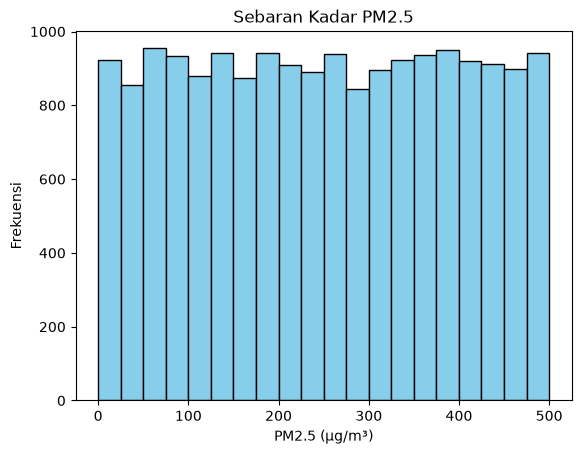

In [83]:
import matplotlib.pyplot as plt

# 1.Histogram untuk PM2.25
plt.hist(df["PM2.5"], bins=20, color='skyblue', edgecolor='black')
plt.title("Sebaran Kadar PM2.5")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frekuensi")
plt.show()

### 1. Interpretasi Histogram Sebaran Kadar PM2.5
Berdasarkan histogram di atas, sebaran kadar PM2.5 menunjukkan pola yang cenderung merata (*uniform*) dari rentang 0 hingga 500 $\mu g/m^3$, dengan tingkat frekuensi kemunculan di setiap kelompok nilai yang relatif seimbang (berkisar antara 850 hingga 950 data). Hal ini mengindikasikan bahwa tidak ada rentang nilai polusi tertentu yang mendominasi secara ekstrem di dalam keseluruhan dataset.

In [84]:
# Median PM2.5 berdasarkan kota
df.groupby("City")["PM2.5"].median()

City
Bangalore    248.8
Chennai      254.0
Delhi        255.4
Kolkata      249.5
Mumbai       247.0
Name: PM2.5, dtype: float64

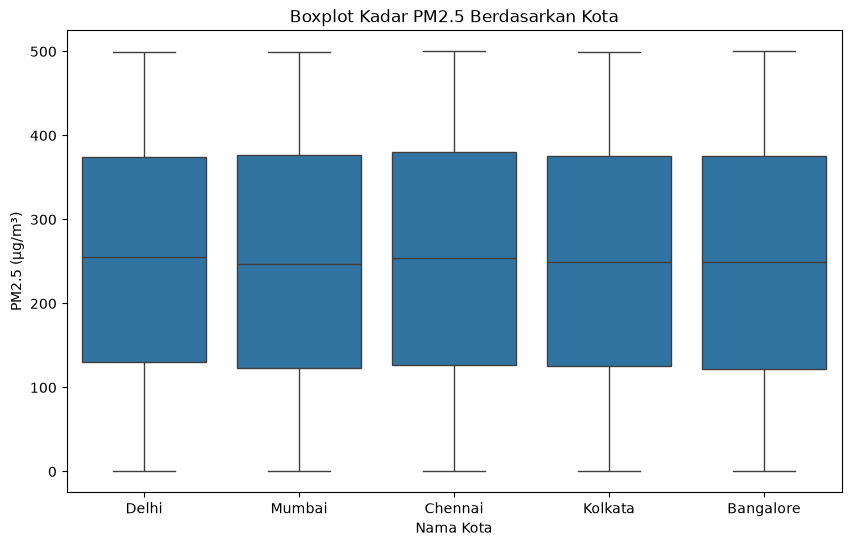

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x="City", y="PM2.5", data=df)
plt.title("Boxplot Kadar PM2.5 Berdasarkan Kota")
plt.xlabel("Nama Kota")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

### 2.Interpretasi Boxplot Perbandingan Kadar PM2.5 Antar Kota
Berdasarkan grafik boxplot di atas, sebaran kadar PM2.5 di kelima kota (Delhi, Mumbai, Chennai, Kolkata, dan Bangalore) menunjukkan pola yang hampir seragam dan identik. 

1. **Nilai Tengah (Median):** Garis tengah pada setiap kotak (*box*) berada di sekitar angka 250 $\mu g/m^3$, yang menunjukkan bahwa tingkat pencemaran rata-rata di kelima kota tersebut berada pada kisaran yang setara.
2. **Rentang Data (IQR & Whiskers):** Kotak utama dan batas bawah-atas (*whiskers*) tersebar secara konsisten dari angka 0 hingga 500 $\mu g/m^3$, menandakan variasi dan rentang nilai polusi yang mirip di setiap wilayah.
3. **Pencilan (*Outliers*):** Berdasarkan aturan $1{,}5 \times IQR$, tidak terlihat adanya titik pencilan di luar batas minimum dan maksimum, yang berarti seluruh data terkonsentrasi secara stabil di dalam rentang tersebut tanpa adanya lonjakan ekstrem yang terisolasi di kota tertentu.

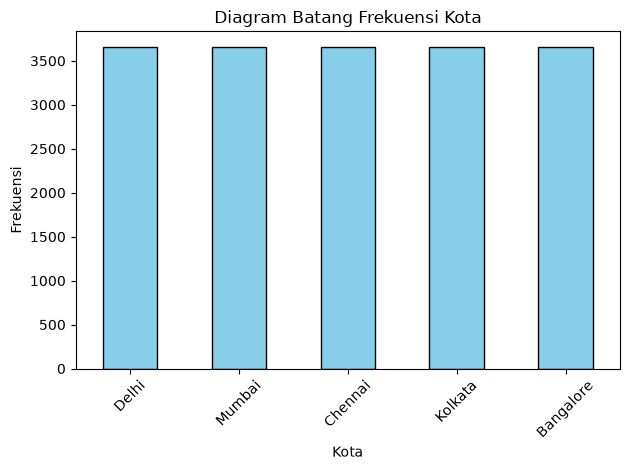

In [86]:
import matplotlib.pyplot as plt

# Ganti "nama_kolom" dengan kolom yang ingin dihitung frekuensinya, misal "City"
df["City"].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Diagram Batang Frekuensi Kota")
plt.xlabel("Kota")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. Interpretasi Diagram Batang Jumlah Data per Kota
Berdasarkan diagram batang di atas, jumlah catatan data untuk setiap kota terdistribusi secara merata dengan tinggi batang yang setara (masing-masing kota memiliki 3.653 entri atau 20% dari total keseluruhan data). Hal ini menunjukkan bahwa porsi data dari kelima wilayah diambil secara seimbang tanpa adanya dominasi jumlah data dari kota tertentu.

## Kesimpulan Analisis Kualitas Udara (PM2.5)

### 1. Ringkasan Hasil Analisis
* **Sebaran Data PM2.5:** Kadar polusi PM2.5 secara keseluruhan tersebar dari rentang 0 hingga 500 $\mu g/m^3$ dengan pola frekuensi yang relatif merata[cite: 5].
* **Distribusi per Kota:** Jumlah data dari kelima kota (Delhi, Mumbai, Chennai, Kolkata, dan Bangalore) terdistribusi secara seimbang, masing-masing dengan porsi yang setara[cite: 5].
* **Perbandingan Median:** Nilai median kadar PM2.5 di kelima kota berada di kisaran angka yang sama (sekitar 250 $\mu g/m^3$), menunjukkan tingkat pencemaran rata-rata yang mirip antarwilayah[cite: 7].

### 2. Temuan Paling Menarik
1. **Konsistensi Sebaran:** Tidak ditemukan adanya lonjakan atau kemiringan ekstrem (miring ke kiri/kanan) pada histogram keseluruhan kadar PM2.5[cite: 5].
2. **Keseimbangan Wilayah:** Setiap kota memiliki jumlah entri data dan profil *boxplot* yang hampir identik, tanpa adanya dominasi pencilan (*outliers*) yang ekstrem di luar batas normal[cite: 5, 7].
3. **Stabilitas Median Antarkota:** Meskipun berasal dari kota-kota besar yang berbeda karakteristik geografisnya, nilai tengah polusi PM2.5 tercatat sangat konsisten di angka 250 $\mu g/m^3$[cite: 7].

### 3. Keterbatasan Data
* **Rentang Nilai yang Terbatas:** Nilai maksimum PM2.5 mentok di angka 500 $\mu g/m^3$, yang kemungkinan merupakan batas atas (*cap*) dari alat ukur atau sistem pencatatan dataset.
* **Kurangnya Variabel Waktu/Musim:** Dataset saat ini belum mencakup informasi mendetail mengenai waktu spesifik (seperti bulan atau musim tertentu) yang dapat menjelaskan fluktuasi polusi secara lebih mendalam.

### 4. Ide Pertanyaan Lanjutan untuk Analisis Berikutnya
* Apakah terdapat korelasi antara tingkat kadar PM2.5 dengan kondisi musim (musim hujan vs musim kemarau) di masing-masing kota?
* Bagaimana tren perubahan kadar PM2.5 jika dianalisis berdasarkan rentang waktu harian atau bulanan?

| Alat | Dipakai untuk | Yang kami pelajari |
| :--- | :--- | :--- |
| AI Collaborator | Mengatasi error `KeyError` saat memanggil nama kolom seperti `City` dan `PM2.5`| Cara memastikan penulisan nama kolom pada dataframe harus sama persis dengan dataset asli |
| AI Collaborator | Membuat dan merapikan kode grafik histogram, *boxplot* perbandingan kota, serta diagram batang | Cara membuat visualisasi data dan memahami cara membaca sebaran nilai serta *outliers* |
| AI Collaborator | Menyusun draf interpretasi data, kesimpulan, temuan menarik, keterbatasan data, hingga ide analisis lanjutan | Cara merangkum hasil analisis statistik deskriptif dan perbandingan median per kota ke dalam bahasa laporan |